In [5]:
import sqlite3 as sql
import pandas as pd


#creating data base
db=sql.connect("job_market.db")

#read the files
df_adzuna=pd.read_csv('clean_dataset.csv')
df_kaggle=pd.read_csv('cleaned kaggle dataset.csv')

#convert the dataframe into sql tables

df_adzuna.to_sql('adzuna',db,if_exists='replace',index=False)
df_kaggle.to_sql('kaggle',db,if_exists='replace',index=False)

print("Table Created Successfully")

Table Created Successfully


In [104]:
import matplotlib.pyplot as plt
import seaborn as sns

In [12]:
query=""" select * from adzuna where 1=0 """
result= pd.read_sql_query(query,db)
print(result)

Empty DataFrame
Columns: [id, description, title, created, Company Name, salary_max, salary_min, city, has_python, has_sql, has_excel, has_powerbi, has_tableau]
Index: []


In [27]:
query=""" select * from kaggle where 1=0 """
result= pd.read_sql_query(query,db)
print(result)

Empty DataFrame
Columns: [job_title, company, first_seen, search_city, search_country, job level, job_type, job_summary, job_skills, city, has_python, has_sql, has_excel, has_powerbi, has_tableau]
Index: []


# Question 1:

## What perecentage of postings mention Python, SQL, Excel, Power BI, Tableau in Adzuna (India) vs. Kaggle (Global)?


In [73]:
query_adzuna ="""
Select 
SUM(has_python) as count_python,
sum(has_sql) as count_sql,
sum(has_excel) as count_excel,
sum(has_powerbi) as count_powerbi,
sum(has_tableau) as count_tableau,
count(*) as total_data
FROM adzuna"""
result_adzuna= pd.read_sql_query(query_adzuna,db)
print("-----ADZUNA(INDIA)------")
print(result_adzuna)

-----ADZUNA(INDIA)------
   count_python  count_sql  count_excel  count_powerbi  count_tableau  \
0            36         63           38             30             16   

   total_data  
0         250  


In [74]:
query_kaggle ="""
Select 
SUM(has_python) as count_python,
sum(has_sql) as count_sql,
sum(has_excel) as count_excel,
sum(has_powerbi) as count_powerbi,
sum(has_tableau) as count_tableau,
count(*) as total_data
FROM kaggle"""
result_kaggle= pd.read_sql_query(query_kaggle,db)
print("-----Kaggle(FOREIGN)------")
print(result_kaggle)

-----Kaggle(FOREIGN)------
   count_python  count_sql  count_excel  count_powerbi  count_tableau  \
0          1021       1848          970            784           1057   

   total_data  
0        2736  


In [82]:
Data=["count_python","count_sql","count_excel","count_powerbi","count_tableau"]
percentage_adzuna={}
percentage_kaggle={}

for skills in Data:
    pct_val=skills.replace('count_','percentage_')
    percentage_adzuna[pct_val]= (result_adzuna[skills]/result_adzuna['total_data']*100).round(2)
    percentage_kaggle[pct_val]= (result_kaggle[skills]/result_kaggle['total_data']*100).round(2)

df1 = pd.DataFrame(percentage_adzuna)
df2 = pd.DataFrame(percentage_kaggle)

print("-----ADZUNA(INDIA)------")
print(df1)

print("-----Kaggle(FOREIGN)------")
print(df2)

df1.to_csv('1_adzuna_percent.csv',index=False)
df2.to_csv('1_kaggle_percent.csv',index=False)



-----ADZUNA(INDIA)------
   percentage_python  percentage_sql  percentage_excel  percentage_powerbi  \
0               14.4            25.2              15.2                12.0   

   percentage_tableau  
0                 6.4  
-----Kaggle(FOREIGN)------
   percentage_python  percentage_sql  percentage_excel  percentage_powerbi  \
0              37.32           67.54             35.45               28.65   

   percentage_tableau  
0               38.63  


### SQL demand appears substantially higher in the Global dataset (67.5%) vs. India live postings (25.2%) — though part of this gap may reflect Adzuna's description truncation limiting skill detection

Text(0.5, 0, 'Skills')

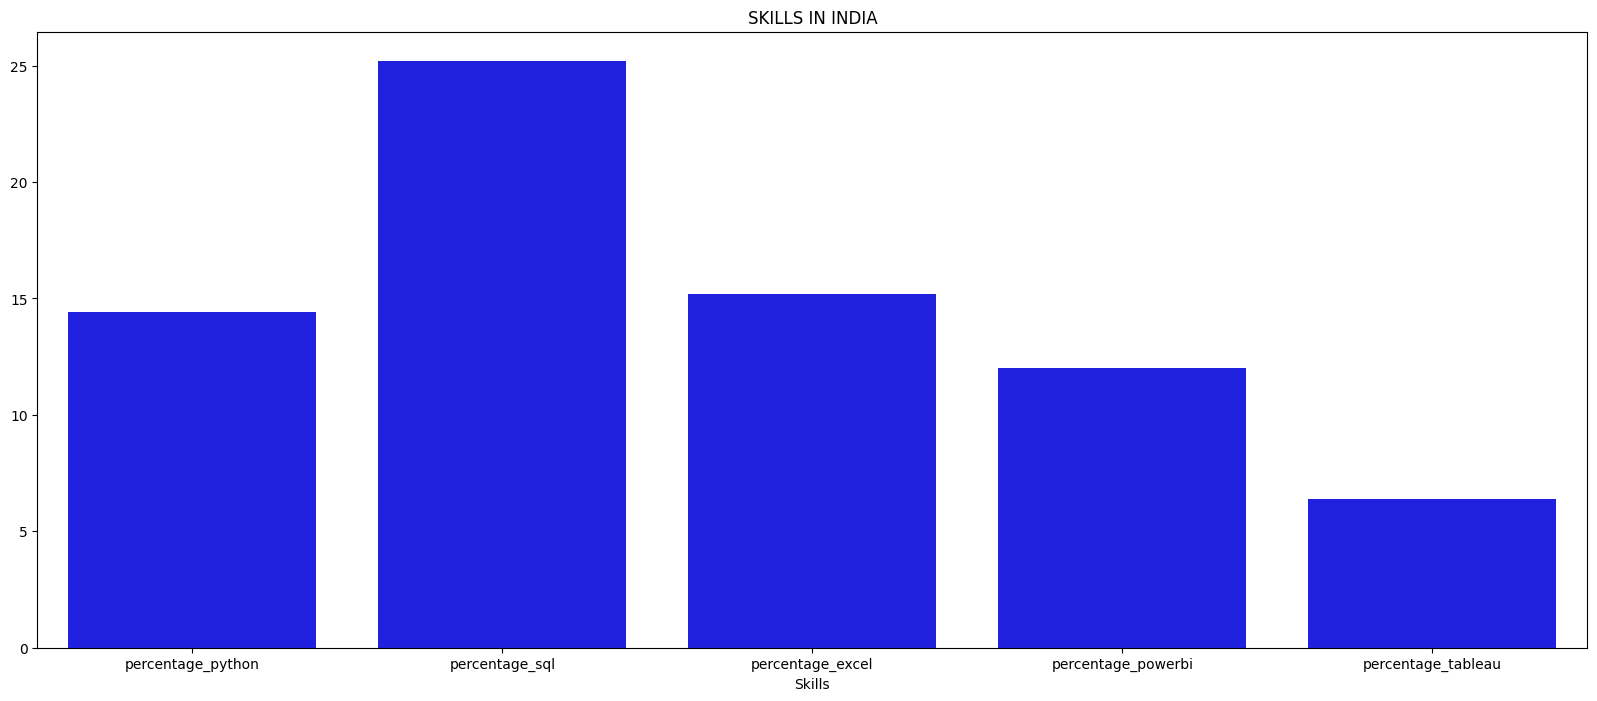

In [44]:
plt.figure(figsize=(20,8))
sns.barplot(percentage_adzuna,color="Blue",)
plt.title("SKILLS IN INDIA")
plt.xlabel("Skills",)


Text(0.5, 0, 'Skills')

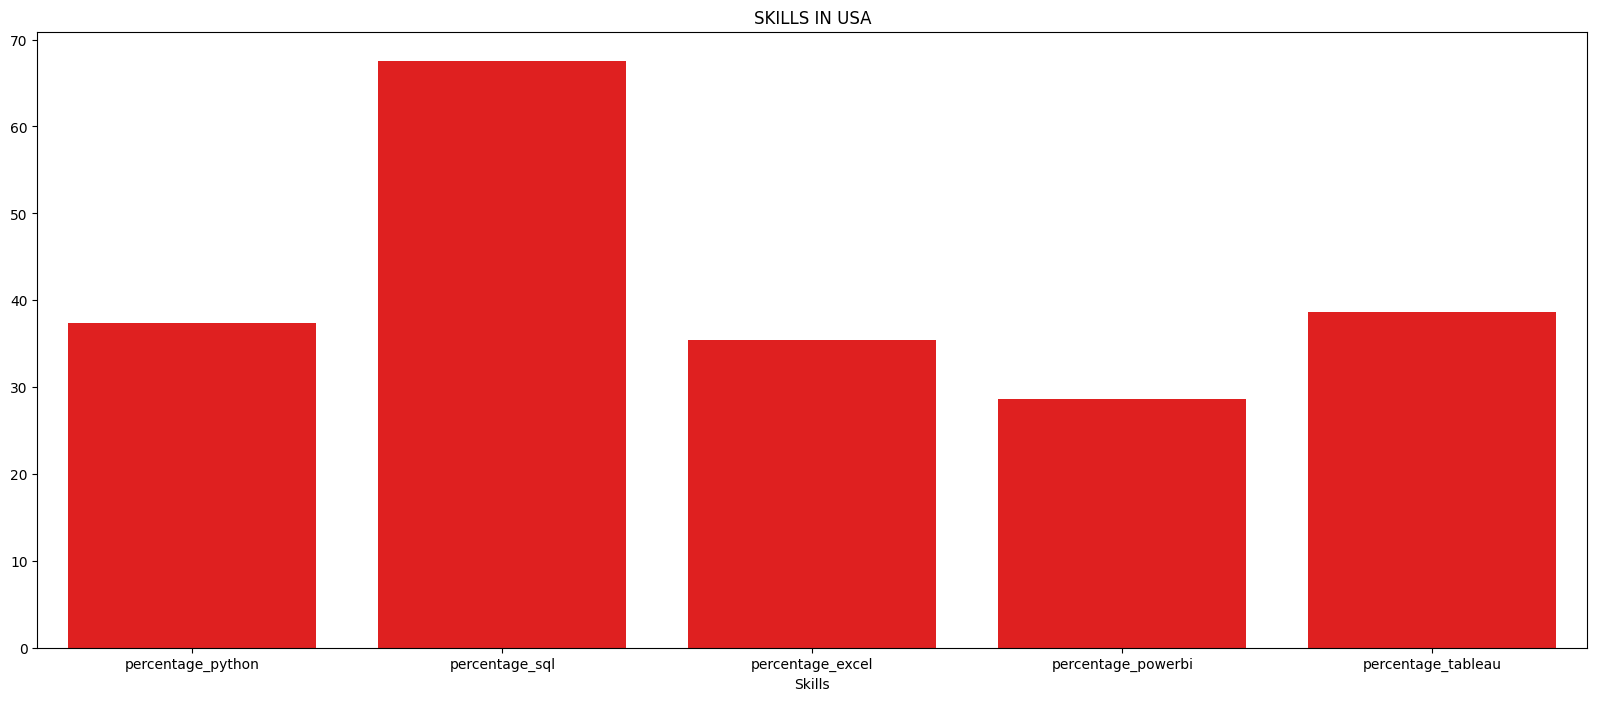

In [45]:
plt.figure(figsize=(20,8))
sns.barplot(percentage_kaggle,color="Red")
plt.title("SKILLS IN USA")
plt.xlabel("Skills")

### 2.Which cities in India (Adzuna) show the most Data Analyst postings, and what skills do they demand most?
###   Same for Global (Kaggle) — which cities dominate, and their skill patterns?

In [71]:
query2=""" select 
city,
count(city) as Number_of_jobs ,
dense_rank() over (order by count(city) desc) as JOB_RANK,
total(has_python) as python,
total(has_sql) as sql,
total(has_excel) as excel,
total(has_powerbi) as power_bi,
total(has_tableau) as tableau
from adzuna group by city  """
res=pd.read_sql_query(query2,db)
print(res)
res.to_csv('2_adzuna.csv',index=False)

                  city  Number_of_jobs  JOB_RANK  python   sql  excel  \
0            Bangalore              76         1    13.0  21.0   12.0   
1     other/state only              65         2    11.0  15.0    8.0   
2               Mumbai              27         3     1.0   7.0    8.0   
3                 Pune              17         4     4.0   5.0    2.0   
4            Hyderabad              15         5     0.0   2.0    0.0   
5                Noida               9         6     1.0   3.0    2.0   
6              Chennai               8         7     0.0   1.0    1.0   
7              Gurgaon               7         8     1.0   2.0    0.0   
8                Delhi               6         9     0.0   1.0    1.0   
9             Vadodara               4        10     0.0   0.0    1.0   
10             Kolkata               3        11     2.0   2.0    1.0   
11              Jaipur               2        12     0.0   1.0    0.0   
12           Ahmedabad               2        12   

In [70]:
query3=""" select 
city,
count(city) as Number_of_jobs ,
dense_rank() over (order by count(city) DESC) as JOB_RANK,
total(has_python) as python,
total(has_sql) as sql,
total(has_excel) as excel,
total(has_powerbi) as power_bi,
total(has_tableau) as tableau
from kaggle group by city  """
resu=pd.read_sql_query(query3,db)
print(resu)
resu.to_csv('2_kaggle.csv',index=False)

               city  Number_of_jobs  JOB_RANK  python    sql  excel  power_bi  \
0           Unknown             211         1    81.0  160.0   59.0      51.0   
1            London              84         2    43.0   56.0   24.0      22.0   
2          New York              82         3    29.0   57.0   25.0      17.0   
3           Atlanta              54         4    23.0   45.0   19.0      15.0   
4        Washington              48         5    24.0   35.0   18.0      19.0   
..              ...             ...       ...     ...    ...    ...       ...   
748     Aliso Viejo               1        32     0.0    0.0    1.0       0.0   
749         Alberta               1        32     1.0    1.0    1.0       1.0   
750   Adelaide Lead               1        32     0.0    0.0    0.0       0.0   
751        Abingdon               1        32     1.0    1.0    1.0       0.0   
752  Abbots Salford               1        32     1.0    1.0    0.0       1.0   

     tableau  
0       74.0

# Question 3:
### How many skills does a typical posting expect at once (1 vs 2 vs 3+)? Compare India vs Global — do employers expect more multi-tool proficiency in one market vs the other? Which 2 skills most commonly appear together (e.g., SQL+Python vs SQL+Excel)?

In [4]:
import pandas as pd
import sqlite3 as sql
db=sql.connect('job_market.db')

## For adzuna

In [69]:
sql_code="""SELECT 
    skill_count,
    COUNT(*) as number_of_postings
FROM (
    SELECT 
        (has_python + has_sql + has_excel + has_powerbi + has_tableau) as skill_count
    FROM adzuna
) 
GROUP BY skill_count
ORDER BY skill_count"""
total=pd.read_sql_query(sql_code,db)
print(total)
total.to_csv('3_adzuna_skill_count.csv',index=False)

   skill_count  number_of_postings
0            0                 156
1            1                  40
2            2                  31
3            3                  14
4            4                   6
5            5                   3


In [68]:
import itertools
import pandas as pd

df = pd.read_csv('clean_dataset.csv')  # or however you're loading adzuna

skills = ['has_python', 'has_sql', 'has_excel', 'has_powerbi', 'has_tableau']

pair_counts = {}

for skill1, skill2 in itertools.combinations(skills, 2):
    pair_name = f"{skill1}_and_{skill2}"
    count = ((df[skill1]) & (df[skill2])).sum()
    pair_counts[pair_name] = count

pair_df = pd.DataFrame(list(pair_counts.items()), columns=['skill_pair', 'count'])
pair_df = pair_df.sort_values('count', ascending=False)
print(pair_df)
pair_df.to_csv('3_adzuna_pairs_of_skills.csv',index=False)

                    skill_pair  count
0       has_python_and_has_sql     29
5      has_sql_and_has_powerbi     19
4        has_sql_and_has_excel     19
9  has_powerbi_and_has_tableau     14
7    has_excel_and_has_powerbi     14
1     has_python_and_has_excel     10
6      has_sql_and_has_tableau     10
2   has_python_and_has_powerbi      9
8    has_excel_and_has_tableau      8
3   has_python_and_has_tableau      7


## For Kaggle

In [67]:
sql_code="""SELECT 
    skill_count,
    COUNT(*) as number_of_postings
FROM (
    SELECT 
        (has_python + has_sql + has_excel + has_powerbi + has_tableau) as skill_count
    FROM kaggle
) 
GROUP BY skill_count
ORDER BY skill_count"""
total=pd.read_sql_query(sql_code,db)
print(total)
total.to_csv('3_skill_count.csv',index=False)

   skill_count  number_of_postings
0            0                 410
1            1                 595
2            2                 667
3            3                 571
4            4                 427
5            5                  66


In [65]:
import itertools
import pandas as pd

df1 = pd.read_csv('cleaned kaggle dataset.csv')  # or however you're loading adzuna

skills = ['has_python', 'has_sql', 'has_excel', 'has_power_bi', 'has_tableau']

pair_counts = {}

for skill1, skill2 in itertools.combinations(skills, 2):
    pair_name = f"{skill1}_and_{skill2}"
    count = ((df1[skill1]) & (df1[skill2])).sum()
    pair_counts[pair_name] = count

pair_df = pd.DataFrame(list(pair_counts.items()), columns=['skill_pair', 'count'])
pair_df = pair_df.sort_values('count', ascending=False)
print(pair_df)

pair_df.to_csv('3_pairs_of_skills.csv',index=False)

                     skill_pair  count
6       has_sql_and_has_tableau    930
0        has_python_and_has_sql    929
4         has_sql_and_has_excel    646
3    has_python_and_has_tableau    633
5      has_sql_and_has_power_bi    632
9  has_power_bi_and_has_tableau    484
2   has_python_and_has_power_bi    386
8     has_excel_and_has_tableau    380
7    has_excel_and_has_power_bi    311
1      has_python_and_has_excel    271


# Question 4:
### Among the ~77 rows with salary data, does mentioning Python/SQL/Power BI correlate with a higher salary range? Which city (within Adzuna) has the highest average salary, where data exists?

In [63]:
query=""" select city,avg(salary_max) as avg_salary from adzuna where 
salary_max != 'Nan' group by city order by avg(salary_max)"""
op=pd.read_sql_query(query,db)
print(op)
op.to_csv('4_city_with_highest_salary.csv',index=False)

                city    avg_salary
0               Kota  2.500000e+05
1             Jaipur  3.000000e+05
2             Bhopal  4.000000e+05
3         Coimbatore  7.000000e+05
4           Vadodara  7.000000e+05
5          Hyderabad  8.000000e+05
6             Nagpur  8.000000e+05
7              Delhi  8.500000e+05
8          Ahmedabad  9.000000e+05
9              Noida  9.250000e+05
10         Mangalore  1.000000e+06
11  other/state only  1.021053e+06
12              Pune  1.250000e+06
13            Mumbai  1.300000e+06
14         Bangalore  1.394828e+06
15           Gurgaon  1.500000e+06


In [61]:
#for python
query_python=""" select 
has_python,
count(*),
avg(salary_max),
avg(salary_min) 
from adzuna 
where salary_max != 'NaN' 
group by has_python """
jop_op1=pd.read_sql_query(query_python,db)
jop_op1.to_csv('4_salary_based_on_python.csv',index=False)


# For SQl


query_sql=""" select 
has_sql,
count(*),
avg(salary_max),
avg(salary_min) 
from adzuna 
where salary_max != 'NaN' 
group by has_sql """
jop_op2=pd.read_sql_query(query_sql,db)
jop_op2.to_csv('4_salary_based_on_sql.csv',index=False)

#For Power_BI


query_Powerbi=""" select 
has_powerbi,
count(*),
avg(salary_max),
avg(salary_min) 
from adzuna 
where salary_max != 'NaN' 
group by has_powerbi"""
jop_op3=pd.read_sql_query(query_Powerbi,db)
jop_op3.to_csv('4_salary_based_on_Powerbi.csv',index=False)


Queries=[query_python,query_sql,query_Powerbi]

for i in Queries:
    output = pd.read_sql_query(i,db)
    print(f"--------------------------------------------------------------------")
    print(output)



--------------------------------------------------------------------
   has_python  count(*)  avg(salary_max)  avg(salary_min)
0           0        62     1.152419e+06    697307.692308
1           1        15     1.096667e+06    550000.000000
--------------------------------------------------------------------
   has_sql  count(*)  avg(salary_max)  avg(salary_min)
0        0        50     1.123000e+06    639268.292683
1        1        27     1.175926e+06    723913.043478
--------------------------------------------------------------------
   has_powerbi  count(*)  avg(salary_max)  avg(salary_min)
0            0        70     1.165714e+06    678983.050847
1            1         7     9.000000e+05    560000.000000


# Question 5:
## Do "Associate" (fresher-friendly) postings ask for different/fewer skills than "Mid-senior" ones? This is your most direct evidence for "what should I focus on as a fresher

In [59]:
job_sql = """ SELECT 
    "job level",
    COUNT(*) as number_of_postings,
    total(has_python) as python,
    total(has_sql) as sql,
    total(has_excel) as excel,
    total(has_powerbi) as power_bi,
    total(has_tableau) as tableau
FROM kaggle
GROUP BY "job level"
"""
jop_op=pd.read_sql_query(job_sql,db)
print(jop_op)

jop_op.to_csv('5_job_level.csv',index=False)


    job level  number_of_postings  python     sql  excel  power_bi  tableau
0   Associate                 557   199.0   363.0  231.0     135.0    223.0
1  Mid senior                2179   822.0  1485.0  739.0     649.0    834.0


In [8]:
job="""SELECT 
    "job level",
    COUNT(*) as total_postings,
    ROUND(100.0 * SUM(has_sql) / COUNT(*), 1) as pct_sql,
    ROUND(100.0 * SUM(has_python) / COUNT(*), 1) as pct_python,
    ROUND(100.0 * SUM(has_excel) / COUNT(*), 1) as pct_excel,
    ROUND(100.0 * SUM(has_power_bi) / COUNT(*), 1) as pct_powerbi,
    ROUND(100.0 * SUM(has_tableau) / COUNT(*), 1) as pct_tableau
FROM kaggle
GROUP BY "job level" """
jop_op=pd.read_sql_query(job,db)
print(jop_op)
jop_op.to_csv('52_job_level.csv',index=False)

    job level  total_postings  pct_sql  pct_python  pct_excel  pct_powerbi  \
0   Associate             557     65.2        35.7       41.5         24.2   
1  Mid senior            2179     68.2        37.7       33.9         29.8   

   pct_tableau  
0         40.0  
1         38.3  


#  Question 6:
## Which companies post the most Data Analyst roles in each dataset? 

In [58]:
sql_comp=""" 
select "Company Name", 
count("Company Name") as Total_posting
From adzuna group by "Company Name" order by count("Company Name") desc"""
op_comp=pd.read_sql_query(sql_comp,db)
print(op_comp)
op_comp.to_csv('6_adzuna_job.csv')

                       Company Name  Total_posting
0                     Not specified             10
1                             Capco              9
2                 Wissen Technology              4
3                     Multi Recruit              4
4                               EXL              4
..                              ...            ...
186                      Ameriprise              1
187  American Technology Consulting              1
188                          Amazon              1
189           Allime Tech Solutions              1
190        ARC Gate Private Limited              1

[191 rows x 2 columns]


In [ ]:
sql_comp=""" 
select Company, count(Company) as Total_posting
From kaggle group by Company order by count(Company) desc"""
op_comp=pd.read_sql_query(sql_comp,db)
print(op_comp)
op_comp.to_csv('6_kaggle_job.csv',index=False)

                        company  Total_posting
0                         Agoda             67
1           Steneral Consulting             55
2                Insight Global             26
3                     Wahve LLC             25
4                 ClearanceJobs             25
...                         ...            ...
1500  A-Line Staffing Solutions              1
1501                         2K              1
1502                        257              1
1503            24 Seven Talent              1
1504             2020 Companies              1

[1505 rows x 2 columns]


### ----------------------------------- THE END ------------------------------------------